<a href="https://colab.research.google.com/github/PittuSaiPrathvik/xyz/blob/main/EDA_And_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import os
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
os.makedirs("week2_outputs", exist_ok=True)
os.makedirs("week2_outputs/figures", exist_ok=True)
os.makedirs("week2_outputs/tables", exist_ok=True)

print("Output folders created.")

Output folders created.


In [7]:
import pandas as pd
import io
import requests
import zipfile

# Direct URL to the zip archive
zip_url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"

response = requests.get(zip_url)

with zipfile.ZipFile(io.BytesIO(response.content)) as outer_zip:
    # Print available files inside the archive to be safe
    filenames = outer_zip.namelist()

    # Check if the inner zip 'student.zip' exists inside the main zip
    if 'student.zip' in filenames:
        inner_zip_bytes = outer_zip.read('student.zip')
        with zipfile.ZipFile(io.BytesIO(inner_zip_bytes)) as inner_zip:
            math_df = pd.read_csv(inner_zip.open("student-mat.csv"), sep=";")
            portuguese_df = pd.read_csv(inner_zip.open("student-por.csv"), sep=";")
    else:
        # Fallback if files are directly extracted without nested zip
        math_file = [f for f in filenames if f.endswith("student-mat.csv")][0]
        por_file = [f for f in filenames if f.endswith("student-por.csv")][0]

        math_df = pd.read_csv(outer_zip.open(math_file), sep=";")
        portuguese_df = pd.read_csv(outer_zip.open(por_file), sep=";")

print("Mathematics dataset:", math_df.shape)
print("Portuguese dataset:", portuguese_df.shape)

Mathematics dataset: (395, 33)
Portuguese dataset: (649, 33)


In [8]:
math_df["subject"] = "Mathematics"
portuguese_df["subject"] = "Portuguese"

print(math_df.head())
print(portuguese_df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  freetime goout  Dalc  Walc  health absences  G1  G2  G3      subject  
0        3     4     1     1       3        6   5   6   6  Mathematics  
1        3     3     1     1       3        4   5   5   6  Mathematics  
2        3     2     2     3       3       10   7   8  10  Mathematics  
3        2     2     1     1       5        2  15  14  15  Mathematics  
4        3     2     1     2       5        4   6  10  10  Mathematics  

[5 rows x 34 columns]
  school sex  age address famsize Pstatus  Medu  Fed

In [9]:
df = pd.concat(
    [math_df, portuguese_df],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

df.head()

Combined dataset shape: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Mathematics
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Mathematics
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Mathematics
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Mathematics
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Mathematics


In [10]:
df.to_csv(
    "week2_outputs/student_performance_combined.csv",
    index=False
)

print("Dataset saved.")


Dataset saved.


In [11]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 1044
Number of columns: 34

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'subject']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [13]:
summary = df.describe(include="all").T

summary

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,1044,2,GP,772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1044,2,F,591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1044.0,NaN,NaN,NaN,16.726054,1.239975,15.0,16.0,17.0,18.0,22.0
address,1044,2,U,759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,1044,2,GT3,738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,1044,2,T,923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,1044.0,NaN,NaN,NaN,2.603448,1.124907,0.0,2.0,3.0,4.0,4.0
Fedu,1044.0,NaN,NaN,NaN,2.387931,1.099938,0.0,1.0,2.0,3.0,4.0
Mjob,1044,5,other,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,1044,5,other,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
summary.to_csv(
    "week2_outputs/tables/dataset_summary.csv"
)

In [15]:
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing Percentage": (
        missing.values / len(df) * 100
    ).round(2)
})

missing_table

,Column,Missing Values,Missing Percentage
0,school,0,0.0
1,sex,0,0.0
2,age,0,0.0
3,address,0,0.0
4,famsize,0,0.0
5,Pstatus,0,0.0
6,Medu,0,0.0
7,Fedu,0,0.0
8,Mjob,0,0.0
9,Fjob,0,0.0


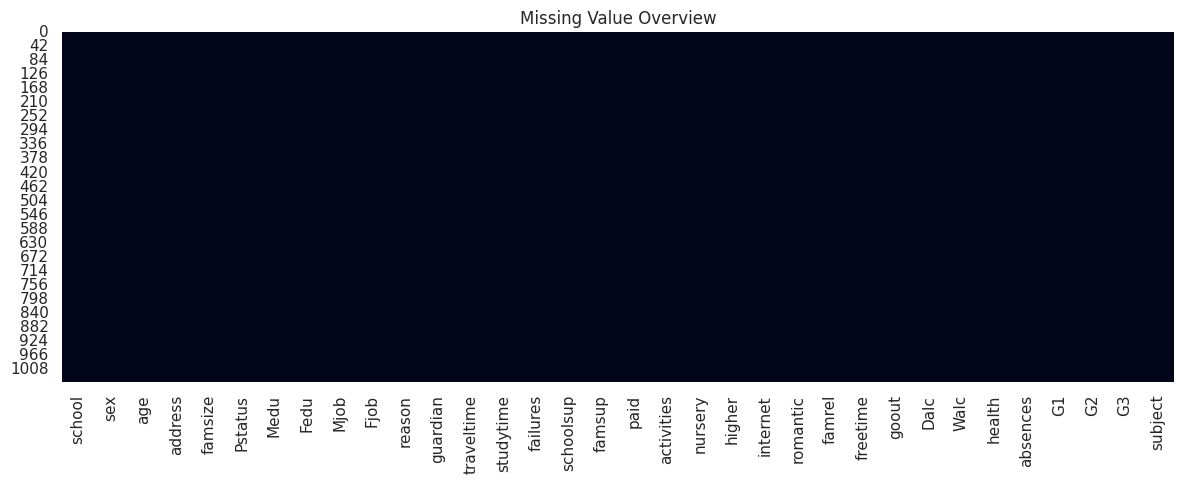

In [16]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Value Overview")
plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/missing_values.png",
    dpi=300
)

plt.show()

In [17]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [18]:
print("Numerical columns:")
print(
    df.select_dtypes(
        include=np.number
    ).columns.tolist()
)

print("\nCategorical columns:")
print(
    df.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']


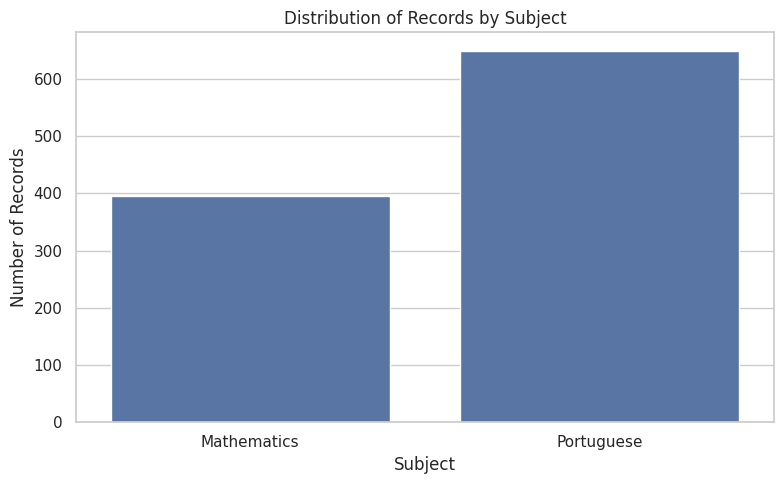

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="subject"
)

plt.title("Distribution of Records by Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/subject_distribution.png",
    dpi=300
)

plt.show()

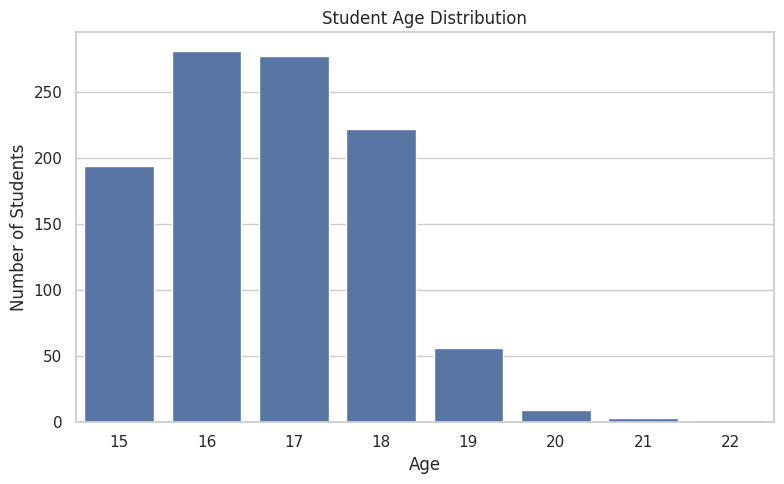

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="age"
)

plt.title("Student Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/age_distribution.png",
    dpi=300
)

plt.show()

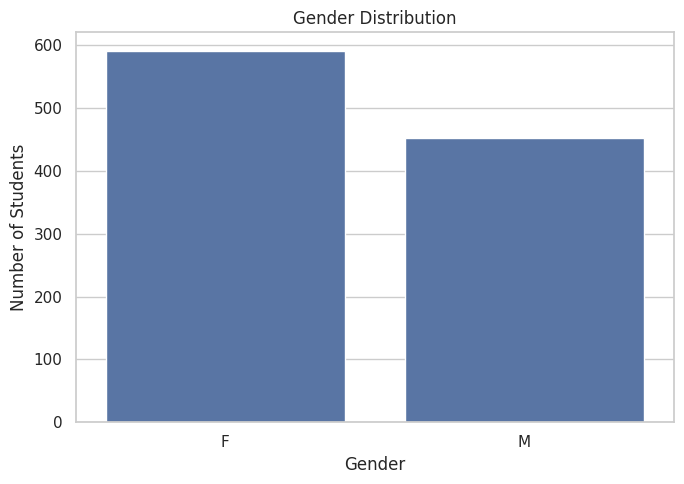

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sex"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/gender_distribution.png",
    dpi=300
)

plt.show()

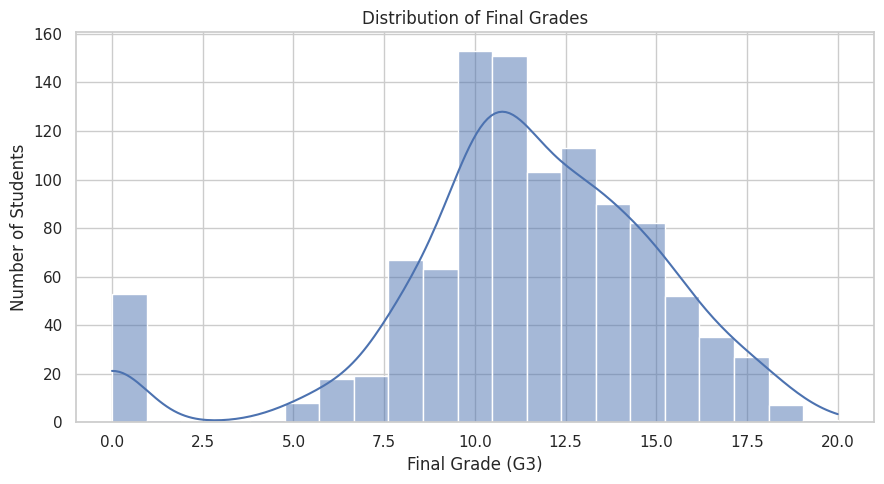

In [22]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="G3",
    bins=21,
    kde=True
)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/final_grade_distribution.png",
    dpi=300
)

plt.show()

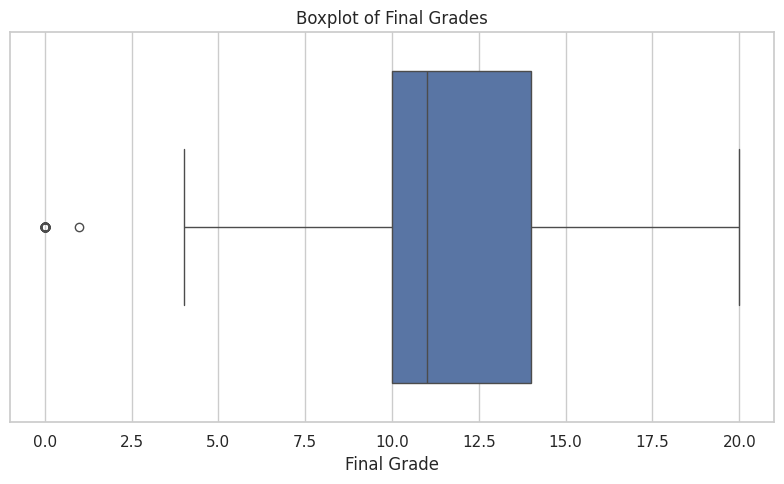

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["G3"]
)

plt.title("Boxplot of Final Grades")
plt.xlabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/final_grade_boxplot.png",
    dpi=300
)

plt.show()

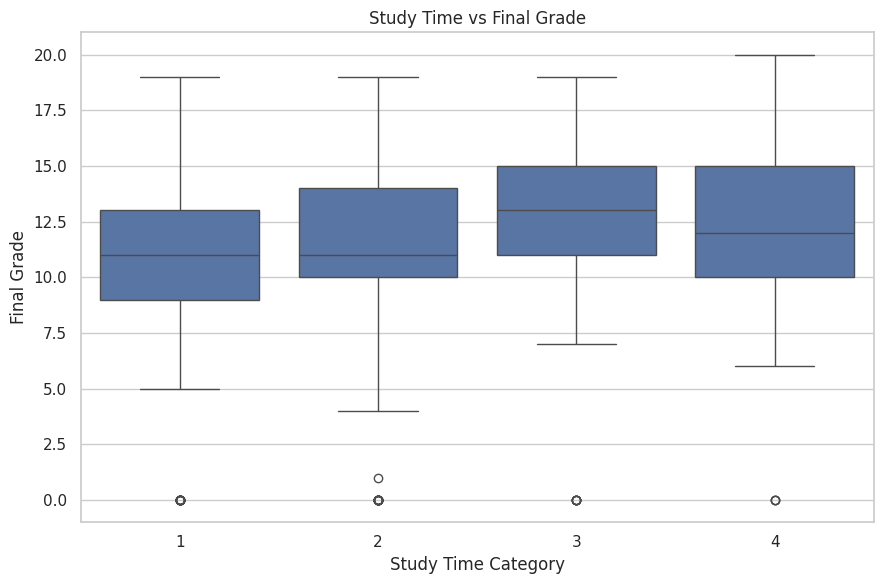

In [24]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="studytime",
    y="G3"
)

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/studytime_vs_grade.png",
    dpi=300
)

plt.show()


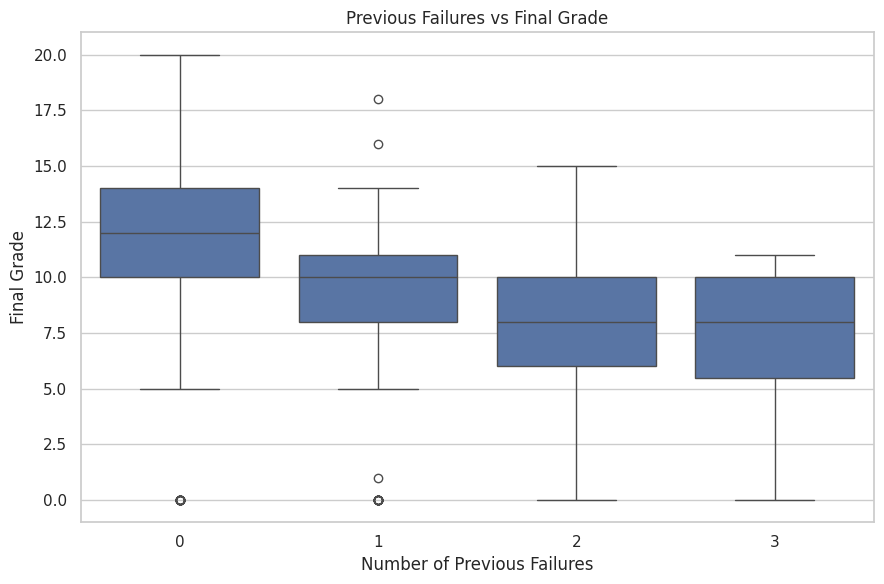

In [25]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="failures",
    y="G3"
)

plt.title("Previous Failures vs Final Grade")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/failures_vs_grade.png",
    dpi=300
)

plt.show()

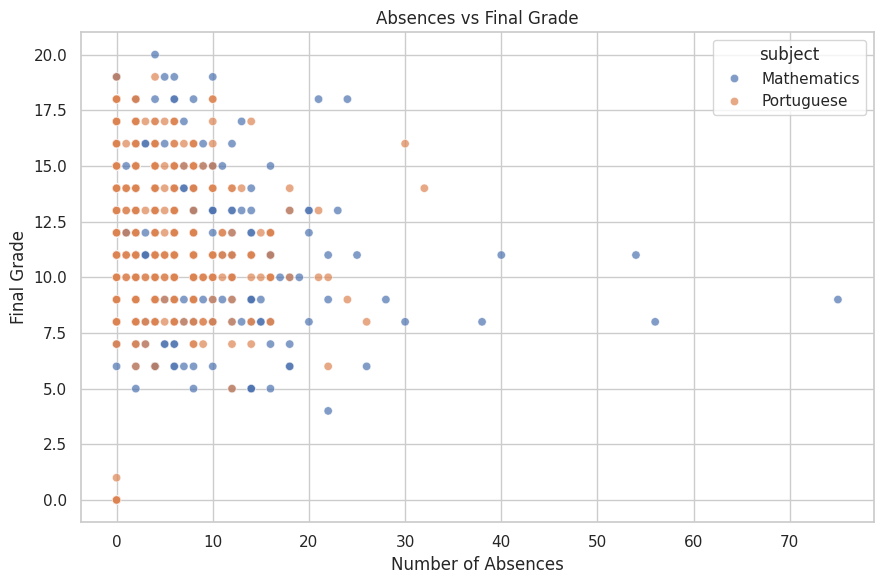

In [26]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="absences",
    y="G3",
    hue="subject",
    alpha=0.7
)

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/absences_vs_grade.png",
    dpi=300
)

plt.show()

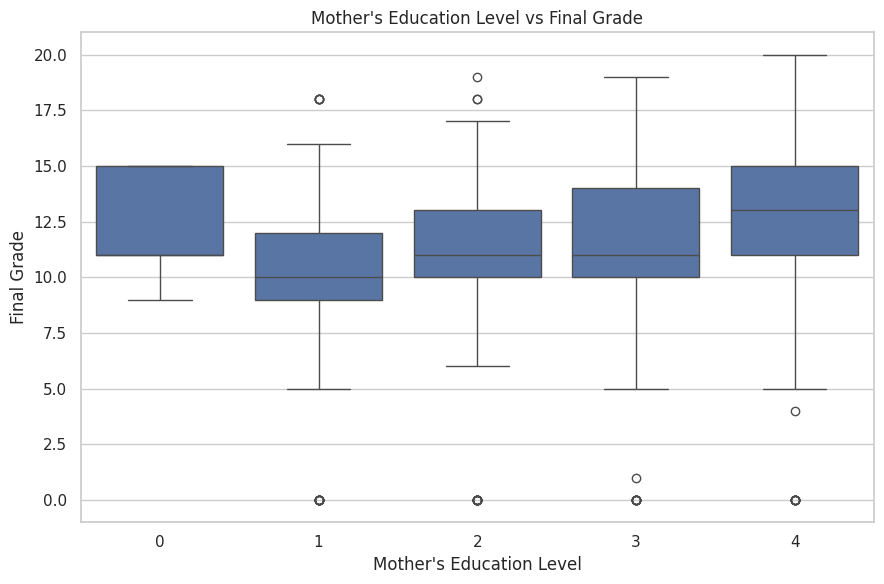

In [27]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Medu",
    y="G3"
)

plt.title("Mother's Education Level vs Final Grade")
plt.xlabel("Mother's Education Level")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/mother_education_vs_grade.png",
    dpi=300
)

plt.show()

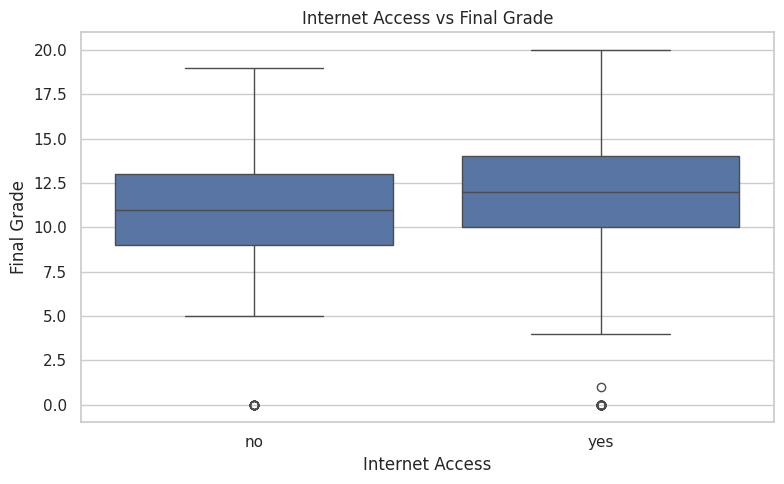

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="internet",
    y="G3"
)

plt.title("Internet Access vs Final Grade")
plt.xlabel("Internet Access")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/internet_vs_grade.png",
    dpi=300
)

plt.show()

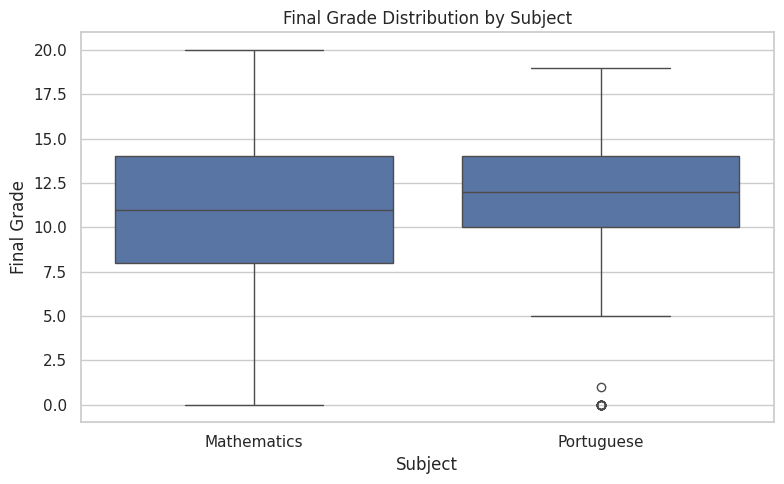

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="subject",
    y="G3"
)

plt.title("Final Grade Distribution by Subject")
plt.xlabel("Subject")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/subject_vs_grade.png",
    dpi=300
)

plt.show()

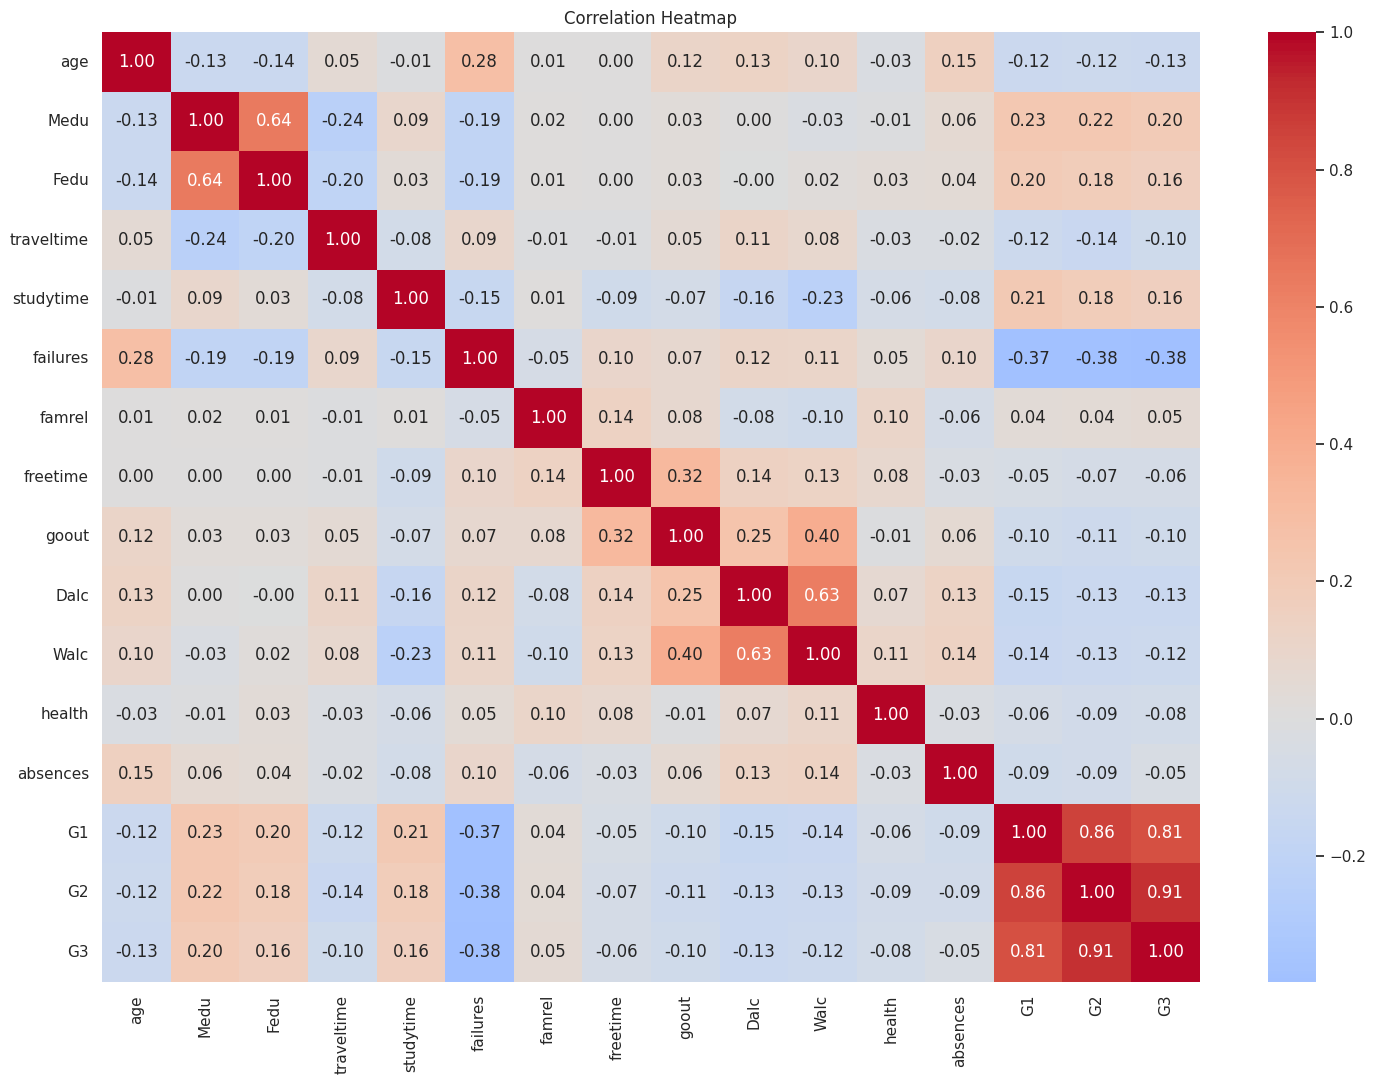

In [30]:
numeric_df = df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr()

plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/correlation_heatmap.png",
    dpi=300
)

plt.show()

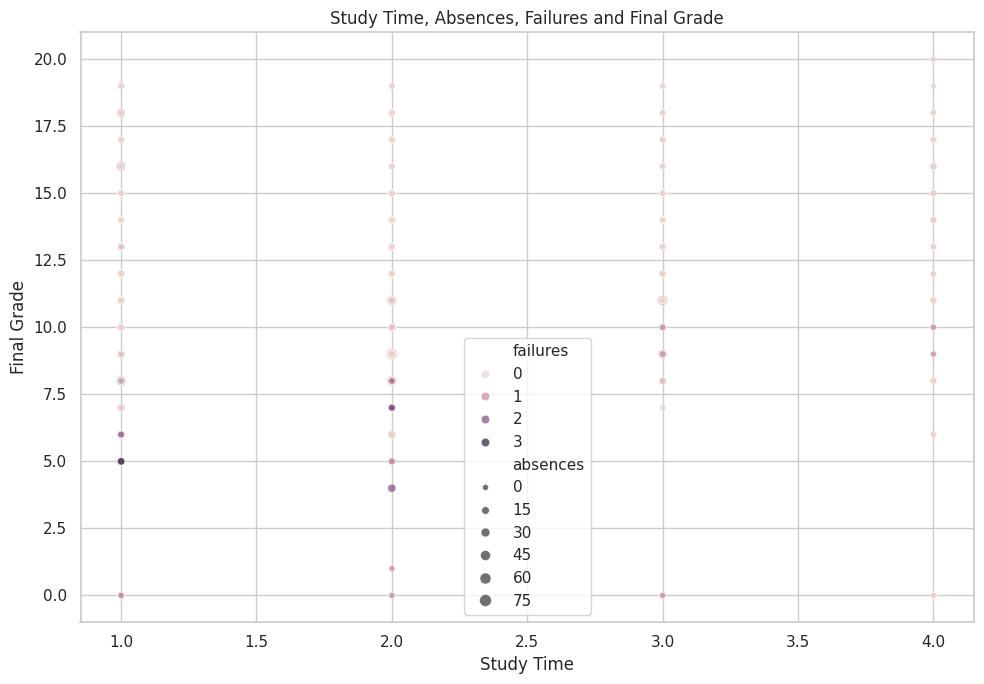

In [31]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="studytime",
    y="G3",
    size="absences",
    hue="failures",
    alpha=0.7
)

plt.title(
    "Study Time, Absences, Failures and Final Grade"
)

plt.xlabel("Study Time")
plt.ylabel("Final Grade")

plt.tight_layout()

plt.savefig(
    "week2_outputs/figures/multivariate_analysis.png",
    dpi=300
)

plt.show()

In [32]:
numeric_columns = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2",
    "G3"
]

outlier_results = []

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_df = pd.DataFrame(
    outlier_results
)

outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,age,16.0,18.0,2.0,13.0,21.0,2
1,Medu,2.0,4.0,2.0,-1.0,7.0,0
2,Fedu,1.0,3.0,2.0,-2.0,6.0,0
3,traveltime,1.0,2.0,1.0,-0.5,3.5,24
4,studytime,1.0,2.0,1.0,-0.5,3.5,62
5,failures,0.0,0.0,0.0,0.0,0.0,183
6,famrel,4.0,5.0,1.0,2.5,6.5,77
7,freetime,3.0,4.0,1.0,1.5,5.5,64
8,goout,2.0,4.0,2.0,-1.0,7.0,0
9,Dalc,1.0,2.0,1.0,-0.5,3.5,52


In [33]:
outlier_df.to_csv(
    "week2_outputs/tables/outlier_analysis.csv",
    index=False
)

In [34]:
fig = px.scatter(
    df,
    x="studytime",
    y="G3",
    color="subject",
    size="absences",
    hover_data=[
        "age",
        "sex",
        "failures",
        "internet"
    ],
    title="Interactive Student Performance Analysis"
)

fig.show()

In [36]:
print("=" * 60)
print("WEEK 2 EDA SUMMARY")
print("=" * 60)

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

print("\nAverage final grade:")
print(round(df["G3"].mean(), 2))

print("\nMedian final grade:")
print(df["G3"].median())

print("\nAverage absences:")
print(round(df["absences"].mean(), 2))

print("\nAverage grade by subject:")
print(
    df.groupby("subject")["G3"]
    .mean()
    .round(2)
)

print("\nAverage grade by study time:")
print(
    df.groupby("studytime")["G3"]
    .mean()
    .round(2)
)

print("\nAverage grade by previous failures:")
print(
    df.groupby("failures")["G3"]
    .mean()
    .round(2)
)

WEEK 2 EDA SUMMARY

Dataset shape:
(1044, 34)

Missing values:
0

Duplicate records:
0

Average final grade:
11.34

Median final grade:
11.0

Average absences:
4.43

Average grade by subject:
subject
Mathematics    10.42
Portuguese     11.91
Name: G3, dtype: float64

Average grade by study time:
studytime
1    10.58
2    11.34
3    12.49
4    12.27
Name: G3, dtype: float64

Average grade by previous failures:
failures
0    12.05
1     8.43
2     7.48
3     6.80
Name: G3, dtype: float64
